# Ch14. 두 가지 주요 개념: 인과성과 비정상성

- 머신러닝: 대부분 상관관계 포착 -> not 인과관계
- 상관관계: 양방향 / 인과관계: 방향성 지정
- 환경 변화에 따라 변하지 않는 관계: 인과관계에서 비롯된 것일 가능성이 높음

[14.1] 인과성
[14.1.1] 그랜저 인과성
- 인과관계에 대한 정의: $(Y_{t+1},\dots,Y_{t+k})|(\mathcal{F}_{Y,t}\cup \mathcal{F}_{X,t}) \quad  \overset{d}{\neq} \quad (Y_{t+1},\dots,Y_{t+k})|\mathcal{F}_{Y,t}$
$\\ \rarr$ X의 궤적이 Y의 궤적을 변경함 ~ X가 Y에 영향을 미친다
- 두 개의 회귀 분석:
$\\ X_t=\sum_{j=1}^ma_jX_{t-j}+\sum_{j=1}^mb_jY_{t-j} + \epsilon_t \\
Y_t=\sum_{j=1}^mc_jX_{t-j}+\sum_{j=1}^md_jY_{t-j} + \nu_t$
- 하나의 $b_j$라도 0이 아닌 경우 Y가 X를 그랜저 인과함
- 하나의 $c_j$라도 0이 아닌 경우 X가 Y를 그랜저 인과함
- Statistically, 귀무가설 $b_1=...=b_m=0$: 피셔 분포 통해 검증됨

In [1]:
import import_ipynb

Index(['stock_id', 'date', 'Advt_12M_Usd', 'Advt_3M_Usd', 'Advt_6M_Usd',
       'Asset_Turnover', 'Bb_Yld', 'Bv', 'Capex_Ps_Cf', 'Capex_Sales',
       'Cash_Div_Cf', 'Cash_Per_Share', 'Cf_Sales', 'Debtequity', 'Div_Yld',
       'Dps', 'Ebit_Bv', 'Ebit_Noa', 'Ebit_Oa', 'Ebit_Ta', 'Ebitda_Margin',
       'Eps', 'Eps_Basic', 'Eps_Basic_Gr', 'Eps_Contin_Oper', 'Eps_Dil', 'Ev',
       'Ev_Ebitda', 'Fa_Ci', 'Fcf', 'Fcf_Bv', 'Fcf_Ce', 'Fcf_Margin',
       'Fcf_Noa', 'Fcf_Oa', 'Fcf_Ta', 'Fcf_Tbv', 'Fcf_Toa', 'Fcf_Yld',
       'Free_Ps_Cf', 'Int_Rev', 'Interest_Expense', 'Mkt_Cap_12M_Usd',
       'Mkt_Cap_3M_Usd', 'Mkt_Cap_6M_Usd', 'Mom_11M_Usd', 'Mom_5M_Usd',
       'Mom_Sharp_11M_Usd', 'Mom_Sharp_5M_Usd', 'Nd_Ebitda', 'Net_Debt',
       'Net_Debt_Cf', 'Net_Margin', 'Netdebtyield', 'Ni', 'Ni_Avail_Margin',
       'Ni_Oa', 'Ni_Toa', 'Noa', 'Oa', 'Ocf', 'Ocf_Bv', 'Ocf_Ce', 'Ocf_Margin',
       'Ocf_Noa', 'Ocf_Oa', 'Ocf_Ta', 'Ocf_Tbv', 'Ocf_Toa', 'Op_Margin',
       'Op_Prt_Margin', 'Oper_Ps_Net_

<string>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


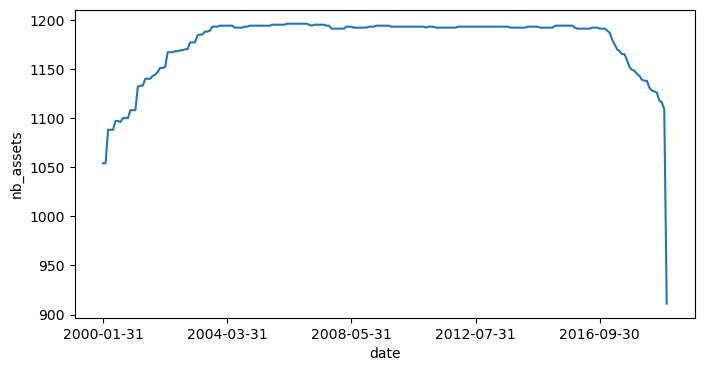

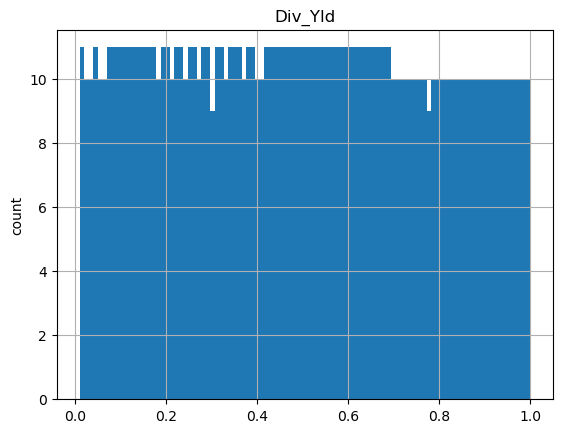

In [2]:
from Ch1 import data_ml, features, features_short

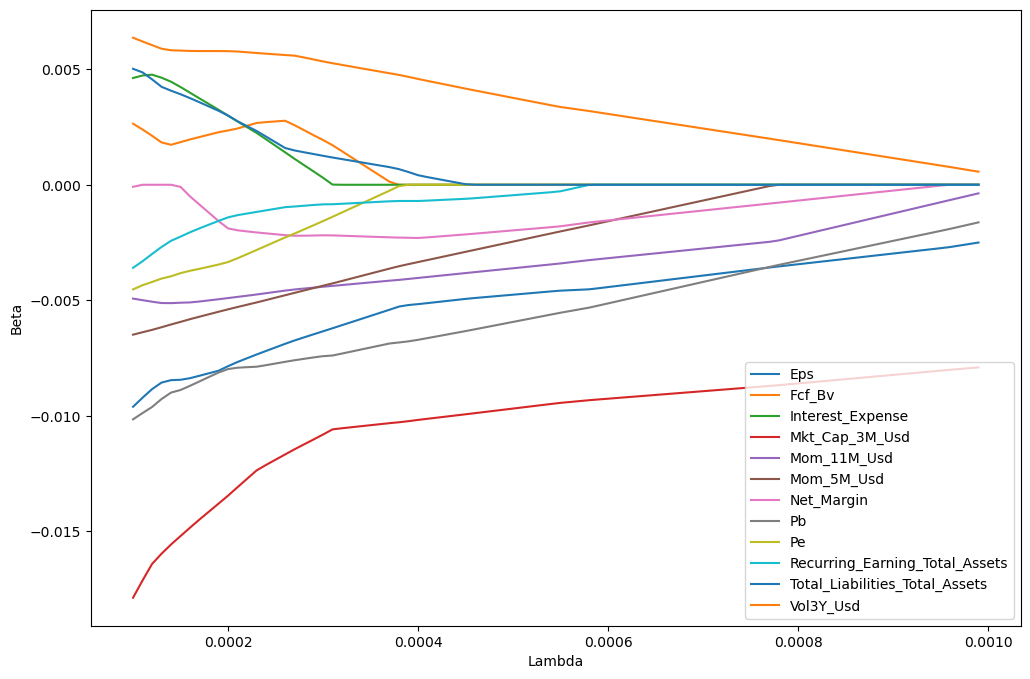

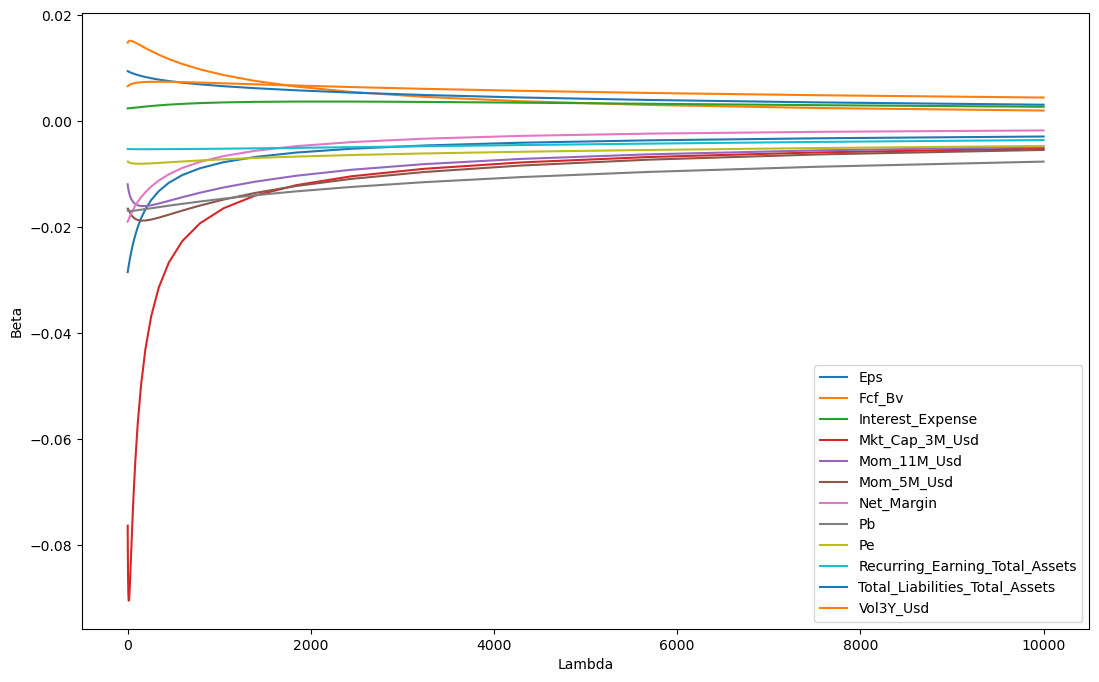

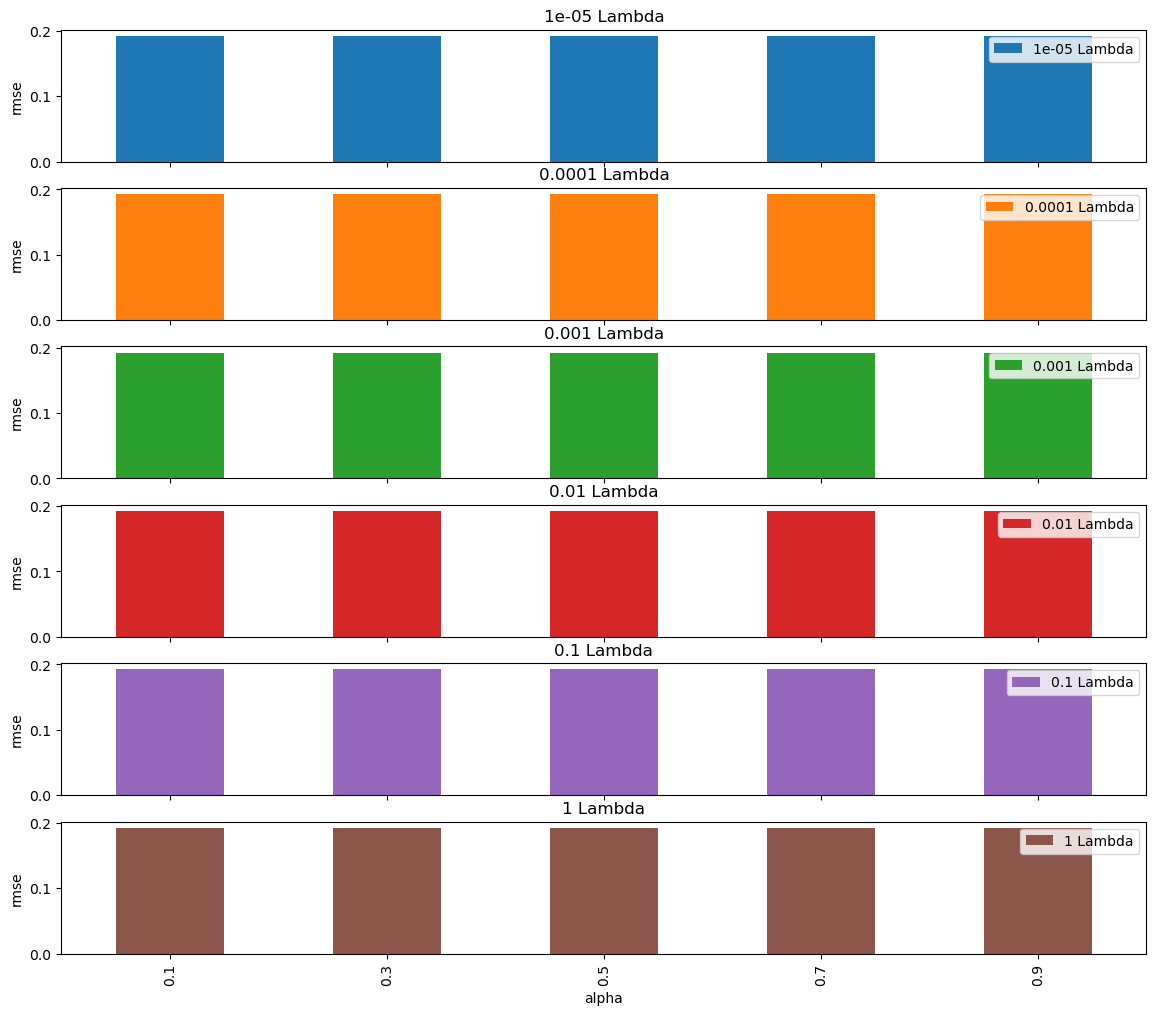

In [4]:
from Ch5 import training_sample

In [9]:
from Ch5 import training_sample

In [10]:
from statsmodels.tsa.stattools import grangercausalitytests
granger=training_sample.loc[training_sample['stock_id']==1,['R1M_Usd', 'Mkt_Cap_6M_Usd']]
fit_granger=grangercausalitytests(granger, maxlag=[6], verbose=True)


Granger Causality
number of lags (no zero) 6
ssr based F test:         F=0.6982  , p=0.6515  , df_denom=149, df_num=6
ssr based chi2 test:   chi2=4.5548  , p=0.6020  , df=6
likelihood ratio test: chi2=4.4919  , p=0.6104  , df=6
parameter F test:         F=0.6982  , p=0.6515  , df_denom=149, df_num=6


c:\Users\82103\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


- 방향성 띰
- X가 Y를 그랜저 인과하는지 여부만 테스트 ~ 반대 효과 테스트하려면 함수 인자 반전시키면 됨
- 이 모델은 선형 모델에 국한돼 있음 ~ 비선형성 포함하면 결론 달라질 수 있음

[14.1.2] 인과적 가법성 모델
- P[날씨|do(기압계)]=P[날씨] ~ 기압계를 강제로 표시하도록 개입해도 날씨에 영향을 미치지 않음
- 즉, 기압계가 날씨에 영향을 미치지 않음
1. 구조적 인과관계 모델(SCM): 모델에 계층 구조를 도입함
$\\ X=\epsilon_X \\
Y=f(X,\epsilon_Y)$
- $\epsilon_X$, $\epsilon_Y$: 독립적인 노이즈 변수
- X의 실현: 무작위로 추출됨 -> f를 통해 Y의 실현에 영향을 미침
- 변수를 정점, vertice(노드, node) / 화살표를 에지
- 두 정점이 에지를 통해 연결되는 "이 둘은 인접했다(adjacent)"
- 인접한 시퀀스: 경로(path)
- 방향이 지정된 경로 내에서 가장 먼저 오는 정점: 부모 노드, 바로 뒤에 오는 정점: 자식 노드
- 그래프 by 인접행렬: if 정점 i에서 정점 j까지 에지 -> $A_{ij}=1$, 대각선은 0(자기 루프 금지)
- (ex) $\textbf{A}=\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & 1 \\
0& 0&0
\end{bmatrix}$ : $X \rarr Y \rarr Z$
- 사이클: 루프를 생성하는 특정 유형의 경로 ~ 첫 번째 정점이 마지막 정점이기도 한 경로
- 일반적인 인과관계 모델: 사이클 피하고 유향 비순환 그래프(DAG)로 작업함
- general model: $ X_j=f_j\left(\textbf{X}_{\text{pa}_D(j)},\epsilon_j  \right)$
- $\text{pa}_D(j)$: 그래프 구조 D 내에서 정점 j의 부모 노드 집합
- 가법적 인과 모델: $ X_j=\sum_{k\in \text{pa}_D(j)}f_{j,k}\left(\textbf{X}_{k}  \right)+\epsilon_j$
$\rarr$ 각 변수의 비선형 효과 누적됨

In [12]:
!pip install icpy

In [14]:
import icpy as icpy
import numpy as np
# 노드 B1, B2
B=training_sample[['Mkt_Cap_12M_Usd', 'Vol1Y_Usd']].values
# 노드 C
C=training_sample['R1M_Usd'].values
#"환경"
ExpInd=np.round(np.random.uniform(size=training_sample.shape[0]))
# A 혹은 B가 C의 부모라면 테스트 수행
icpy.invariant_causal_prediction(X=B, y=C, z=ExpInd, alpha=0.1)

ICP(S_hat=array([0, 1]), q_values=array([0., 0.]), p_value=0)

In [16]:
!pip install cdt

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/921.1 kB ? eta -:--:--
   ---------------------------------------- 921.1/921.1 kB 9.1 MB/s  0:00:00
  Created wheel for GPUtil: filename=gputil-1.4.0-py3-none-any.whl size=7442 sha256=87cb7d762985f4890232aa9ccda04944ffc8fcf37e63fc4da3e0a2c7dffa14fd
  Stored in directory: c:\users\82103\appda

In [18]:
!pip install torch

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   - -------------------------------------- 4.2/113.8 MB 25.1 MB/s eta 0:00:05
   --- ------------------------------------ 9.2/113.8 MB 25.2 MB/s eta 0:00:05
   ----- ---------------------------------- 15.5/113.8 MB 26.2 MB/s eta 0:00:04
   -------- ------------------------------- 23.1/113.8 MB 28.5 MB/s eta 0:00:04
   ---------- ----------------------------- 30.9/113.8 MB 30.1 MB/s eta 0:00:03
   ------------- -------------------------- 38.3/113.8 MB 30.8 MB/s eta 0:00:03
   ---------------- ----------------------- 46.4/113.8 MB 31.8 MB/s eta 0:00:03
   ------------------- -------------------- 54.3/113.8 MB 32.4 MB/s eta 0:00:02
   --------------------- ------------------ 61.6/113.8 MB 32.7 MB/s eta 0:00:02
   ----------------------- ---------------- 67.6/113.8 MB 32.3 MB/s eta 0:00:02
   ------------------------- -------------- 73.9/113.8 MB 32.0 MB/s eta 0:00:02
   -------------------------- ------------- 75.5/11

In [20]:
!pip install network

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for network: filename=network-0.1-py3-none-any.whl size=3183 sha256=1bdf300893021793ab461339035f8eb710e66be8fb63270073a12cbfba9d86e7
  Stored in directory: c:\users\82103\appdata\local\pip\cache\wheels\93\07\5a\a207d6b2ad046d88823c537dd409331218b5f55aa206e820ac
Successfully built network


In [22]:
import cdt
import network as nx
import pandas as pd
import matplotlib.pyplot as plt
data_caus=training_sample[features_short+['R1M_Usd']]
dm=np.array(data_caus)
cm=np.corrcoef(dm.T)
df=pd.DataFrame(cm)
# 그래프 라쏘 초기화
glasso=cdt.independence.graph.Glasso()
# 데이터셋에 그래프 라쏘 적용
skeleton=glasso.predict(df)
# pcalg R 라이브러리로부터 PC 알고리듬 도입
model_pc=cdt.causality.graph.PC()
# 모델 추정
graph_pc=model_pc.predict(df, skeleton)
# 모델 플롯
fig=plt.figure(figsize=[10,6])
nx.draw_networkx(model_pc)

R Call errored, is R available ?


FileNotFoundError: [WinError 2] 지정된 파일을 찾을 수 없습니다

[14.1.3] 구조적 시계열 모델
- 두 개의 방정식으로 구동됨
$\\ y_t&=\textbf{Z}_t'\boldsymbol{\alpha}_t+\epsilon_t \\
\boldsymbol{\alpha}_{t+1}& =\textbf{T}_t\boldsymbol{\alpha}_{t}+\textbf{R}_t\boldsymbol{\eta}_t$
- 종속변수: 상태 변수 $\boldsymbol{\alpha}_t$에 오차 항을 더한 선형함수
- 상태변수: 과거값에 또 다른 오차항을 더한 선형함수

In [24]:
!pip install causalimpact

In [25]:
from causalimpact import CausalImpact
stock1_data=data_ml.loc[data_ml['stock_id']==1, :]
struct_data=stock1_data[['Advt_3M_Usd']+features_short]
struct_data.index=pd.RangeIndex(start=0, stop=228, step=1)
pre_period=[0,99]
post_period=[100,199]
impact=CausalImpact(struct_data, pre_period, post_period)
impact.run()
print(impact.summary())
impact.plot()


ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html


AttributeError: module 'pandas.core.dtypes.common' has no attribute 'is_datetime_or_timedelta_dtype'

[14.2] 변화하는 환경 다루기
- 연구 대상이 되는 샘플: 특성화하려는 현상의 고유한 실현
- X와 Y의 관계가 항상 변한다면 관찰에서 어떤 것도 추론하기가 매우 어려움
- 금융의 주요 문제: 시장, 행동, 정책 등이 항상 진화하는 경우가 많음
- 차익 거래의 부재: if 어떤 트레이딩 전략이 항상 효과가 있, 모든 에이전트가 몰려 해당 전략을 채택하고 그에 따라 이익이 사라짐
- 모든 변수(특성 및 레이블)의 다변량 분포: $\mathbb{P}_{XY}=\mathbb{P}_{X}\mathbb{P}_{Y|X}$: 두가지 변화 가능
1. 공변량 이동: $\mathbb{P}_{X}$는 변함 but $\mathbb{P}_{Y|X}$ 는 변하지 않음(관계 유지)
2. 콘셉트 드리프트: $\mathbb{P}_{Y|X}$는 변함 but $\mathbb{P}_{X}$는 변하지 않음 (관계만 변화)
- 환경의 변화(4가지): 급작 / 점진적 / 단계적 / 반복적
- 안전성-가소성 딜레마: 모델 반응성과 안전성 사이의 절충안 ~ 환경 변화에 따라 모델 동적 조정
- 훈련 샘플의 시간적 깊이 변경
- 최근 인스턴스에 더 많은 가중치 할당
$\\ L=\sum_{i=1}^Iw_i(y_i-\textbf{x}_i\textbf{b})^2$

[14.2.1] 비정상성: Another Example
- 가장 기본적 방법: 수익률(상대적 가격 변동)으로 작업 ~ 시간이 지나도 일관되게 움직임
- 정상성: 시간이 지나도 동일하게 유지되는 분포 특성을 가진 현상의 특성
- but 수익률: 평균과 분산이 주기에 따라 모두 변함


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Axes: xlabel='year'>

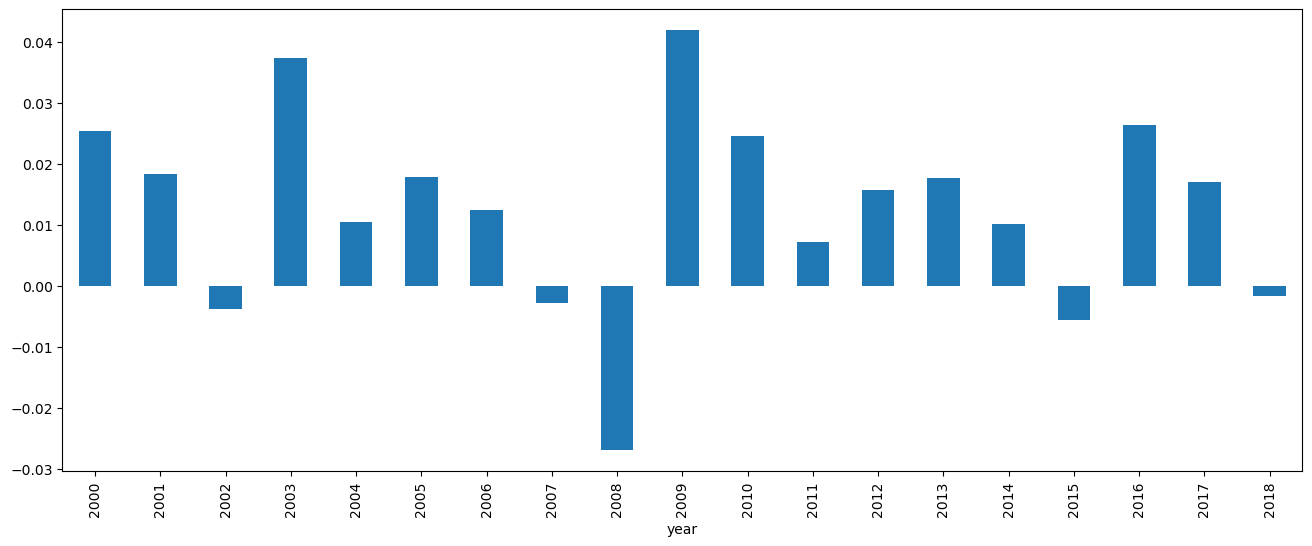

In [26]:
data_ml['year']=pd.to_datetime(data_ml['date']).dt.year
data_ml.groupby('year')['R1M_Usd'].mean().plot.bar(figsize=[16,6])

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (con

<Axes: xlabel='year'>

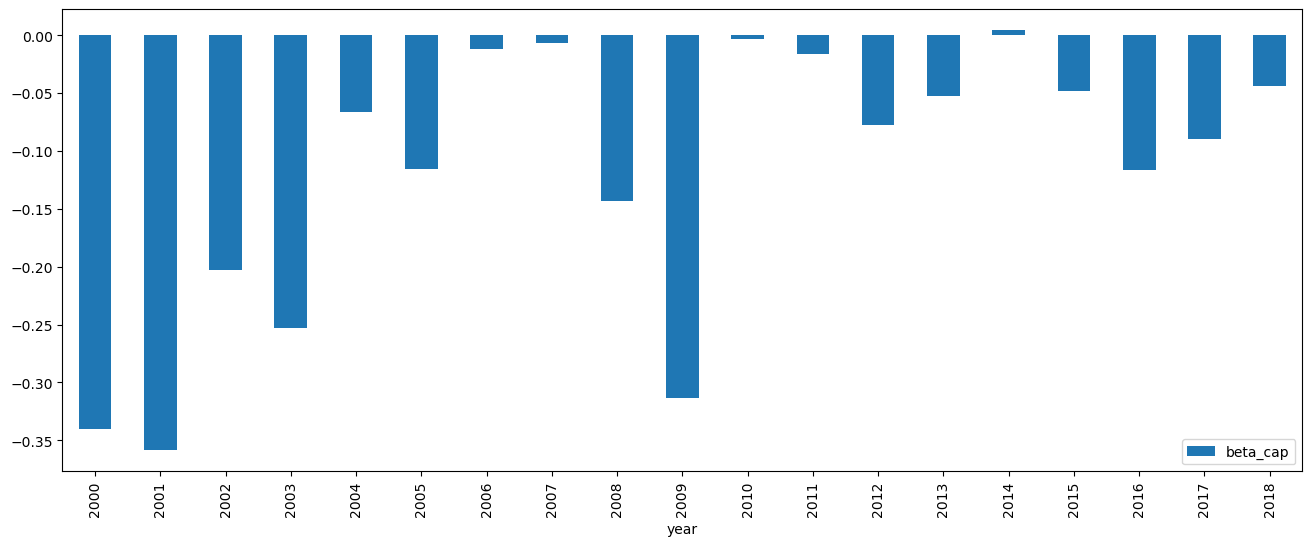

In [28]:
# 지난 6개월 평균 시가 총액 -> 하나의 예측 변수 사용해 순수 특성 회귀 추정
import statsmodels.api as sm
def regress(df):
    model=sm.OLS(df['R6M_Usd'], exog=sm.add_constant(df[['Mkt_Cap_6M_Usd']]))
    return model.fit().params[1]
beta_cap=data_ml.groupby('year').apply(regress)
beta_cap=pd.DataFrame(beta_cap, columns=['beta_cap']).reset_index()
beta_cap.groupby('year').mean().plot.bar(figsize=[16,6])

[14.2.2] 온라인 학습
- 새로운 정보가 점진적으로 도착하고 이러한 흐름의 통합이 반복적으로 수행되는 머신러닝의 하위 집합
- 신경망에서는 가중치를 순차적으로 일괄 업데이트하면 모델을 점진적으로 변경 가능 but 의사결정 트리: 분할이 한번에 결정됨 -> 불가능

(\*) 위드로우 호프 알고리듬
- 모델이 선형($\textbf{y}=\textbf{Xb}+\textbf{e}$)이라고 가정
- b의 값 업데이트: $\textbf{b}_{t+1} \longleftarrow \textbf{b}_t-\eta (\textbf{x}_t\textbf{b}-y_t)\textbf{x}_t'$ ~ 경사하강법

- 데이터셋: 시간별 인덱싱
- 시간: 경계값 T 가짐
- 머신러닝 모델: 일부 매개 변수 $\theta$에 따라 달라짐 -> $f_{\theta}$
- 시간 t에 학습된 모델의 손실 함수 L: 데이터 $(x_t, y_t)$와 $\theta_t$ 통한 모델에 의존함 ~ $L_t(\theta_t)=L(x_t,y_t,\theta_t)$
- 온라인 학습 핵심: 전체 시간 시퀀스에 대한 후회(regret) ~ $R_T=\sum_{t=1}^TL_t(\boldsymbol{\theta}_t)-\underset{\boldsymbol{\theta}^*\in \boldsymbol{\Theta}}{\inf} \ \sum_{t=1}^TL_t(\boldsymbol{\theta}^*)$ ~ (모델에 의해 발생한 총 손실)-(데이터 순서 알고 있었을 때 얻을 수 있었던 최소 손실)
- 매개 변수 업데이트: $\textbf{z}_{t+1}=\boldsymbol{\theta}_t-\eta_t\nabla L_t(\boldsymbol{\theta}_t)$
$\\ \boldsymbol{\theta}_{t+1}=\Pi_S(\textbf{z}_{t+1}), \quad \text{with} \quad \Pi_S(\textbf{u}) = \underset{\boldsymbol{\theta}\in S}{\text{argmin}} \ ||\boldsymbol{\theta}-\textbf{u}||_2$: $\theta_{t+1}$: 중간 선택인 $z_{t+1}$에 가능한 한 가까움
- 적절한 가정 하에서 후회: $R_T \le \frac{G^2}{2H}(1+\log(T))$ 만족
- H: 학습 속도에 대한 스케일링 계수

[14.2.3] 동질적 전이 학습
- $D_s$(소스) & $D_T$(타깃) ~ 2개의 데이터셋 주어짐
- 각 데이터셋에는 고유한 특성 $X^s,\ X^T$, 레이블 $y^s, y^T$ 존재
- 함수 $f^s$를 통해 함수 $f^T$ 개선
- 동질적 전이 학습: 특성 공간이 변하지 않는 경우
- 값이 [0,1]인 2개의 분류자 f & h: 도메인 S에서 이 둘 사이의 평균 오차: $\epsilon_S(f,h)=\mathbb{E}_S[|f(\textbf{x})-h(\textbf{x})|]$
$\\ \rarr \small \epsilon_T(f_T,h)\le \epsilon_S(f_S,h)+\underbrace{2 \sup_B|P_S(B)-P_T(B)|}_{\text{ difference between domains }} + \underbrace{ \min\left(\mathbb{E}_S[|f_S(\textbf{x})-f_T(\textbf{x})|],\mathbb{E}_T[|f_S(\textbf{x})-f_T(\textbf{x})|]\right)}_{\text{difference between the two learning tasks}}, \nonumber$
- f: 각각 최상의 분류기 ~ h가 T에서 생성하는 오차: {S공간의 오차+두 도메인 간 거리+2개의 최적 모델 간 거리} 보다 작음
- minimize in Machine Learning: $ \epsilon_T(f)=\mathbb{E}_T\left[L(\text{y},f(\textbf{X})) \right]$
- $\epsilon_T(f)=\mathbb{E}_S \left[\frac{P_T(\textbf{y},\textbf{X})}{P_S(\textbf{y},\textbf{X})} L(\text{y},f(\textbf{X})) \right]$